# Домашнее задание 1. Подготовка данных для моделирования

В этом домашнем задании вы будете работать с датасетом о кофе и отзывах на него: проводить предобработку данных, анализировать качество и структуру признаков, обрабатывать пропуски и аномалии, а также проектировать новые признаки. Все задания связаны между собой и последовательно подготавливают данные к построению модели машинного обучения, предсказывающей стоимость кофе на основе его характеристик, региона произрастания, степени обжарки и пользовательских оценок.



In [1]:
# Импорт библиотек, дополняйте по необходимости
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from scipy.stats import chi2_contingency
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn import linear_model
from sklearn import model_selection
from sklearn import metrics
from sklearn import preprocessing


In [2]:
warnings.filterwarnings('ignore')

## Знакомство с данными

**Исходный датасет имеет 12 признаков:**
* `uid` — уникальный идентификатор отзыва
* `name` — название кофе;
* `roaster` — название компании обжарщика;
* `roast` — степень обжарки кофе: Dark — темная, Medium-Dark — средне-темная, Medium — средняя, Medium-Light — средне-светлая, Light — светлая;
* `loc_country`— название страны, локация расположения обжарщика;
* `origin_1` — регион_1 произрастания кофе;
* `origin_2` — регион_2 произрастания кофе;
* `rating` — рейтинг кофе;
* `review_date` — дата, когда был оставлен отзыв на кофе;
* `desc_1` — текстовое описание кофе;
* `source_review` — источник отзыва;
* `100g_USD` — цена кофе за 100 г в долларах США (**целевой признак**).

Начнем исследование со знакомства с предоставленными данными. Для решения заданий этого раздела полезно вспомнить пятерку атрибутов pandas для первичного анализа данных. Не забудьте написать **короткие выводы** после каждого задания.


### Задание 1
Прочитайте данные `coffee_analysis.csv`, выведите семпл из нескольких строк и проверьте их размер. Достаточно ли данных для обучения ML-алгоритмов? Напишите код и короткий вывод (достаточно одного предложения).

In [3]:
url = 'https://raw.githubusercontent.com/ivanchiginev3/MIPT-Machine-Learning-Homeworks/refs/heads/main/HW_1/coffee_analysis.csv'
df = pd.read_csv(url)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   uid            1996 non-null   object 
 1   name           1996 non-null   object 
 2   roaster        1996 non-null   object 
 3   roast          1984 non-null   object 
 4   loc_country    1996 non-null   object 
 5   origin_1       1996 non-null   object 
 6   origin_2       1996 non-null   object 
 7   100g_USD       1988 non-null   float64
 8   rating         1996 non-null   object 
 9   review_date    1996 non-null   object 
 10  desc_1         1996 non-null   object 
 11  source_review  1996 non-null   object 
dtypes: float64(1), object(11)
memory usage: 187.3+ KB


In [5]:
df.head()

,uid,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,desc_1,source_review
0,565e9123c6554a48bd0fb1fdc3cd2227,“Sweety” Espresso Blend,A.R.C.,Medium-Light,Hong Kong,Panama,Ethiopia,14.32,"95,0",November 2017,"Evaluated as espresso. Sweet-toned, deeply ric...",cite
1,813a7c786bdf42d6b14e9b489c4ce108,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Guji Zone,Southern Ethiopia,4.70,"92,0",November 2017,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",cite
2,ba6670beda0447499ca11fae5c98c113,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Guji Zone,Oromia Region,4.19,"92,0",November 2017,"Delicate, sweetly spice-toned. Pink peppercorn...",cite
3,baca66cf2ad942b39780e4dbd59138c3,Ethiopia Gedeb Halo Beriti,Big Creek Coffee Roasters,Medium,United States,Gedeb District,Gedeo Zone,4.85,"94,0",November 2017,"Deeply sweet, subtly pungent. Honey, pear, tan...",cite
4,5083c797d68a40e29ccdd6919efe4fc8,Ethiopia Kayon Mountain,Red Rooster Coffee Roaster,Light,United States,Odo Shakiso District,Guji Zone,5.14,"93,0",November 2017,"Delicate, richly and sweetly tart. Dried hibis...",cite


**Вывод:** Данных достаточно

### Задание 2
Проверьте типы признаков и наличие пропусков. Все ли типы столбцов логичные — нет неожиданностей, которые нужно исправить? Также прикиньте, как будете заполнять пропущенные значения. Напишите код и короткий вывод (достаточно одного предложения).

In [6]:
df.dtypes

,0
uid,object
name,object
roaster,object
roast,object
loc_country,object
origin_1,object
origin_2,object
100g_USD,float64
rating,object
review_date,object


In [7]:
pd.isna(df).sum()

,0
uid,0
name,0
roaster,0
roast,12
loc_country,0
origin_1,0
origin_2,0
100g_USD,8
rating,0
review_date,0


**Вывод:** У следующих признаков надо изменить типы:
- `rating`: object -> float;
- `review_date`: object -> datetime.

Пропущенные значения есть в `roast` (так как не знаем степень обжарки лучше удалить) и в `100g_USD` (заполнить медианой).


### Задание 3
Выведите описательную статистику для числовых и категориальных признаков. На первый взгляд, есть ли ошибочные значения, выбросы в данных, неинформативные признаки? Напишите код и короткий вывод (достаточно одного предложения).

Заменим запятую на точку в колонке `rating`

In [8]:
df['rating'] = df['rating'].str.replace(',', '.')

А теперь приведем типы

In [9]:
df['rating'] = df['rating'].astype('float64')

In [10]:
df['review_date'] = df['review_date'].astype('datetime64[ns]')

И выведем описательную статистику для численных признаков:

In [11]:
df.describe(include=['float64'])

,100g_USD,rating
count,1988.000000,1996.000000
mean,9.214437,93.129760
std,11.481039,1.540334
min,0.170000,84.000000
25%,4.930000,92.000000
50%,5.860000,93.000000
75%,8.485000,94.000000
max,132.280000,98.000000


И категориальных

In [12]:
df.describe(include=['object'])

,uid,name,roaster,roast,loc_country,origin_1,origin_2,desc_1,source_review
count,1996,1996,1996,1984,1996,1996,1996,1996,1996
unique,1996,1818,409,5,18,462,253,1993,1
top,cec117f550f64b2cb4879324743c85f4,Espresso Blend,JBC Coffee Roasters,Medium-Light,United States,Guji Zone,Southern Ethiopia,"Evaluated as espresso. Blueberry, Nutella, nar...",cite
freq,1,6,150,1419,1265,136,146,2,1996


**Вывод:** В данных обнаружены следующие проблемы:
- в признаке `100g_USD` есть выбросы,
- признак `source_review` бесполезен (константа)
- `name` и `desc_1`: Содержат почти уникальные значения для каждой строки (1818 и 1993 уникальных значения соответственно),  поэтому в сыром виде они неинформативны.




### Задание 4
За какой период предоставлены данные?

In [13]:
print(f'Данные представлены за период с {df['review_date'].min()} по {df['review_date'].max()}')

Данные представлены за период с 2017-11-01 00:00:00 по 2022-11-01 00:00:00


## Преобразование данных
В этой части исправим очевидные проблемы, обнаруженные ранее и не только; а также создадим несколько новых признаков (Feature Engineering). Это облегчит дальнейший анализ и подготовку данных для моделирования.

### Задание 5
Приведите оставшиеся признаки к подходящим типам, если это необходимо.

In [14]:
df.dtypes

,0
uid,object
name,object
roaster,object
roast,object
loc_country,object
origin_1,object
origin_2,object
100g_USD,float64
rating,float64
review_date,datetime64[ns]


### Задание 6
Посмотрим поближе на признак `loc_country`: выведите уникальные категории и их количество. Нет ли ошибочно записанных стран или названий? Можно объединить? Сделайте это при необходимости (должны остаться только страны).

> Подсказка: Гавайи — это штат США, Гонконг тоже отнесем для простоты к Китаю.

In [15]:
df['loc_country'].value_counts()

,count
loc_country,
United States,1265
Taiwan,547
Hawai'i,70
Canada,30
Guatemala,29
Hong Kong,19
Japan,12
England,6
China,4


In [16]:
df.loc[df['loc_country'] == 'United States And Floyd', 'loc_country'] = 'United States'
df.loc[df['loc_country'] == 'Hawai\'i', 'loc_country'] = 'United States'
df.loc[df['loc_country'] == 'England', 'loc_country'] = 'United Kingdom'
df.loc[df['loc_country'] == 'Hong Kong', 'loc_country'] = 'China'

In [17]:
df['loc_country'].value_counts()

,count
loc_country,
United States,1336
Taiwan,547
Canada,30
Guatemala,29
China,23
Japan,12
United Kingdom,6
Malaysia,3
Australia,2


### Задание 7
Посмотрим поближе на признаки стран `origin_1`, `origin_2`. Унифицированы ли тут названия? При помощи датасета `countries_dict.csv` приведите их к более единообразному виду (только страна, без детализации по региону). После преобразования проверьте, насколько снизилось количество уникальных категорий и какие осталось без пары. Можно ли их оставить как есть или необходимо преобразовать/удалить? Отразите это в выводе.

> Подсказка: для более удобной нормализации названий рекомендуем составить словарь «парафраз-страна», а затем применить его через map к исходным колонкам. Помогут преобразование столбца регионов к списку через `.str.split()` и методы `explode`, `to_dict` из pandas.

**Описание столбцов `countries_dict.csv`:**
* `country` — название страны (к которой нужно привести)
* `regions` — названия регионов этой страны (которые встречаются в признаках `origin_1` `origin_2` датасета)

Загрузим данные из `countries_dict.csv`

In [18]:
url = 'https://raw.githubusercontent.com/ivanchiginev3/MIPT-Machine-Learning-Homeworks/refs/heads/main/HW_1/countries_dict.csv'
countries_dict = pd.read_csv(url)

Создаем словарь 'регион-страна'

In [19]:
countries_dict_exploded = countries_dict.copy()

# Преобразуем строку с регионами в список
countries_dict_exploded['regions_list'] = countries_dict_exploded['regions'].str.split(',')

countries_dict_exploded = countries_dict_exploded.explode('regions_list')

# Создаем словарь: регион -> страна
region_to_country = countries_dict_exploded.set_index('regions_list')['country'].to_dict()

# Очищаем ключи словаря от квадратных скобок [ и ]
region_to_country = {
    re.sub(r'[\[\]]', '', key).strip(): value
    for key, value in region_to_country.items()
}

In [20]:
df['origin_1'] = df['origin_1'].map(region_to_country)
df['origin_2'] = df['origin_2'].map(region_to_country)

In [21]:
print(df['origin_1'].value_counts())
print(f'Количтество уникальных категорий: {df['origin_1'].nunique()}')

origin_1
Ethiopia                            555
Colombia                            247
Kenya                               194
Guatemala                           149
Costa Rica                          113
United States                        94
Panama                               72
Indonesia                            72
El Salvador                          63
Brazil                               58
Peru                                 56
Rwanda                               54
Honduras                             30
Mexico                               29
Ecuador                              27
Burundi                              27
Nicaragua                            22
Papua New Guinea                     22
Yemen                                18
Democratic Republic of the Congo     17
Taiwan                               16
Tanzania                             15
Thailand                             11
Bolivia                               5
Philippines                    

In [22]:
print(df['origin_2'].value_counts())
print(f'Количтество уникальных категорий: {df['origin_2'].nunique()}')

origin_2
Ethiopia                                        556
Colombia                                        243
Kenya                                           182
Guatemala                                       181
Costa Rica                                      105
Panama                                           98
United States                                    96
Indonesia                                        73
Rwanda                                           60
El Salvador                                      46
Peru                                             46
Brazil                                           46
Honduras                                         42
Ecuador                                          27
Mexico                                           25
Nicaragua                                        24
Burundi                                          22
Democratic Republic of the Congo                 22
Papua New Guinea                                 17
Yem

**Вывод:** Количество уникальных категорий значительно снизилось
с 462 до 36 у `orgin_1` и с 253 до 36 у `origin_2`. Можно оставить все как есть





### Задание 8
Сформируем признак `review_len`, который будет содержать длину текстового описания. Кроме этого оно нам больше не понадобится.

In [23]:
df['review_len'] = df['desc_1'].str.len()

In [24]:
df.describe(include='object')

,uid,name,roaster,roast,loc_country,origin_1,origin_2,desc_1,source_review
count,1996,1996,1996,1984,1996,1996,1996,1996,1996
unique,1996,1818,409,5,15,36,36,1993,1
top,cec117f550f64b2cb4879324743c85f4,Espresso Blend,JBC Coffee Roasters,Medium-Light,United States,Ethiopia,Ethiopia,"Evaluated as espresso. Blueberry, Nutella, nar...",cite
freq,1,6,150,1419,1336,555,556,2,1996


### Задание 9
Удалите неинформативные столбцы, которые точно не пригодятся для моделирования + те, что уже прошли предобработку.

In [25]:
df = df.drop(['uid', 'source_review', 'desc_1'], axis = 1)

### Задание 10
Обработайте пропуски во всех столбцах: либо заполните подходящим значением, либо удалите.

In [26]:
df = df.dropna(subset=['roast'])
df['100g_USD'] = df['100g_USD'].fillna(df['100g_USD'].median())

In [27]:
df.isnull().sum()

,0
name,0
roaster,0
roast,0
loc_country,0
origin_1,0
origin_2,0
100g_USD,0
rating,0
review_date,0
review_len,0


### Задание 11
Проверьте наличие дубликатов в получившемся датасете и при необходимости удалите их.

In [28]:
df.duplicated().any()

np.False_

## Разведывательный анализ данных (EDA)

В данной части будем выявлять зависимости между признаками и исследовать их. Это поможет в финальной очистке данных и подготовке их для моделирования.

### Задание 12

Проанализируйте распределение числовых признаков `rating`, `review_len`, `100g_USD`. Проверьте симметричность распределения и наличие выбросов. Запишите в виде короткого вывода.

In [29]:
def outlier_pct(data):
    """
    Возвращает процент выбросов в данных по методу IQR
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[(data < lower) | (data > upper)]
    return round(len(outliers) / len(data) * 100, 2)

In [30]:
def stats(data):
    """
    Возвращает статистику для анализа
    """
    return data.skew(), outlier_pct(data), data.mean(), data.median()

In [31]:
def statistics_visualization(data, column_name='rating', bins=15):
    """
    Визуализирует статистику для конкретного числового признака
    """
    skewness, outliers_pct_val, mean_val, median_val = stats(data)

    # Определяем диапазон для оси X
    x_min, x_max = data.min(), data.max()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # VIOLIN PLOT
    sns.violinplot(y=data, ax=ax1, color='#04819e', linewidth=2, inner='box')
    ax1.set_title(f'Распределение {column_name}', fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel(column_name.capitalize(), fontsize=12)
    ax1.grid(True, alpha=0.3, axis='y')

    # Статистика в рамке
    stats_text = (
        f" Статистика:\n"
        f" Асимметрия: {skewness:.3f}\n"
        f" Выбросы: {outliers_pct_val}%\n"
        f" Среднее: {mean_val:.2f}\n"
        f" Медиана: {median_val}"
    )

    ax1.text(0.03, 0.97, stats_text,
             transform=ax1.transAxes,
             fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='#F0F0F0',
                      alpha=0.9, edgecolor='#4C72B0', linewidth=1.5))

    # ГИСТОГРАММА
    sns.histplot(x=data, bins=bins, kde=True, ax=ax2,
                color='#04819e', edgecolor='white', linewidth=1)

    ax2.set_title(f'Распределение частот', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel(column_name.capitalize(), fontsize=12)
    ax2.set_ylabel('Частота', fontsize=12)
    ax2.grid(True, alpha=0.3)

    # Добавляем линии на гистограмму
    ax2.axvline(x=mean_val, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Среднее')
    ax2.axvline(x=median_val, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Медиана')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

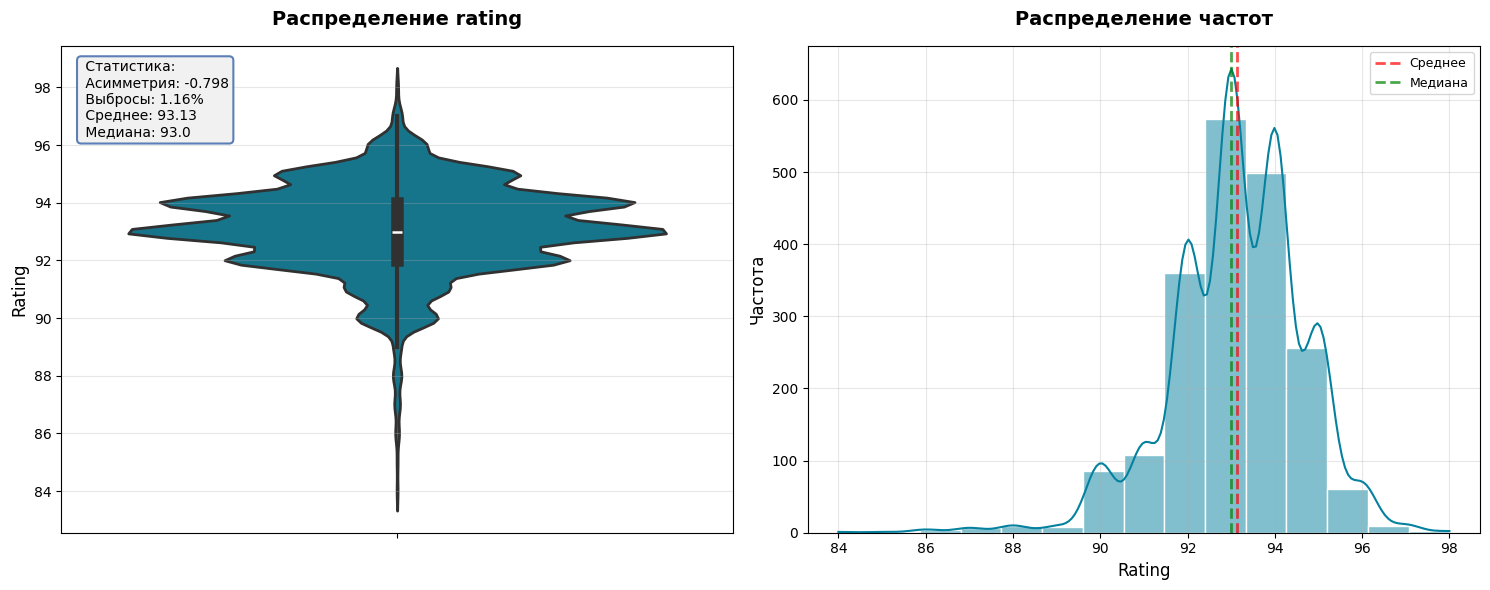

In [32]:
statistics_visualization(df['rating'], 'rating')

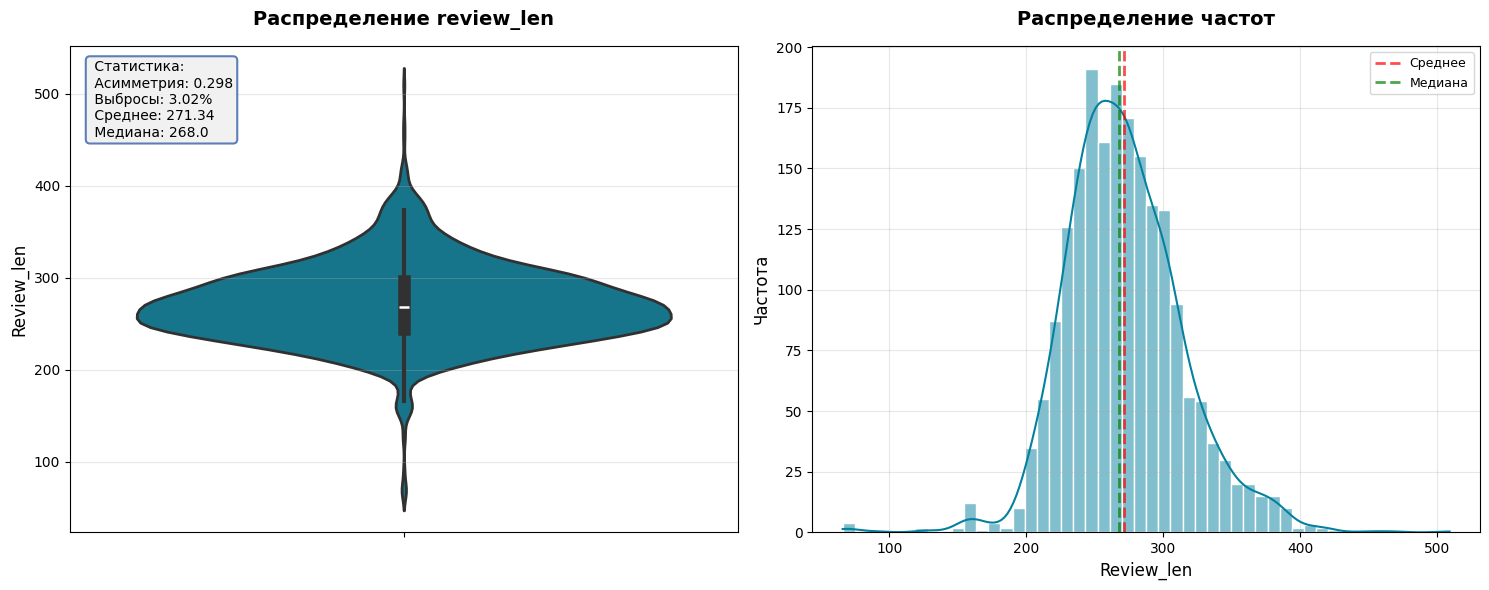

In [33]:
statistics_visualization(df['review_len'], 'review_len', bins=50)

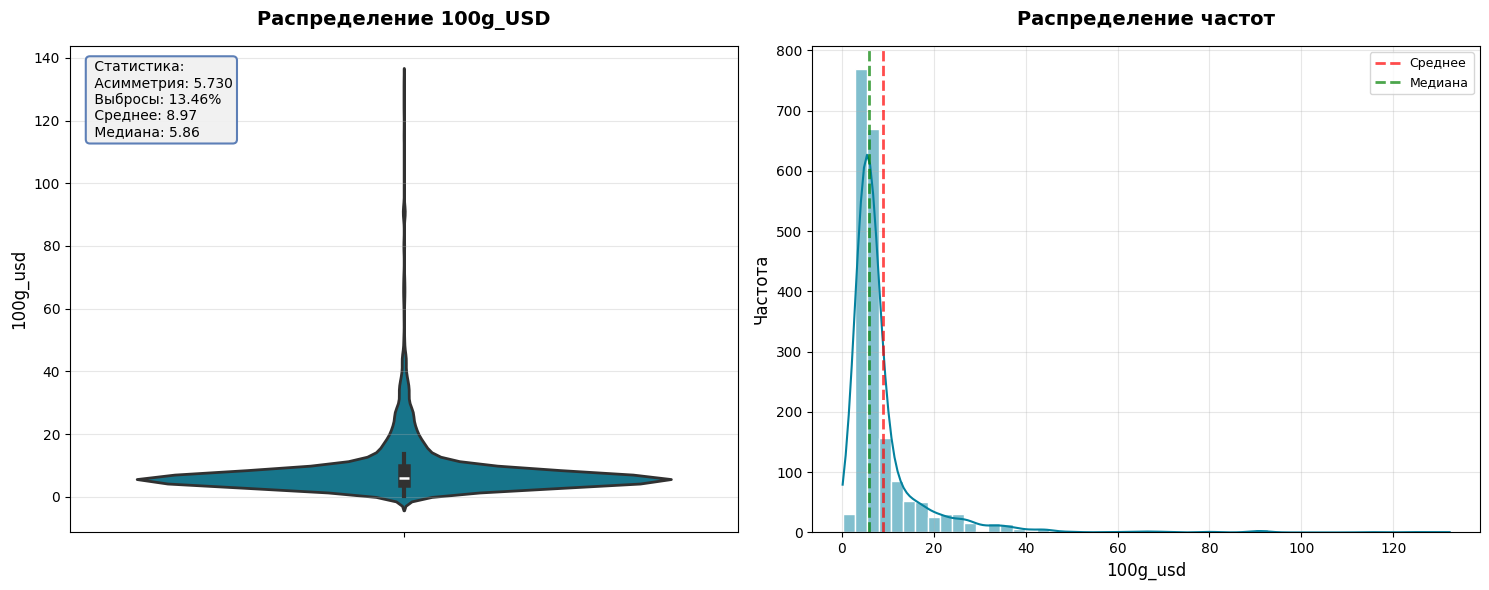

In [34]:
statistics_visualization(df['100g_USD'], '100g_USD', bins=50)

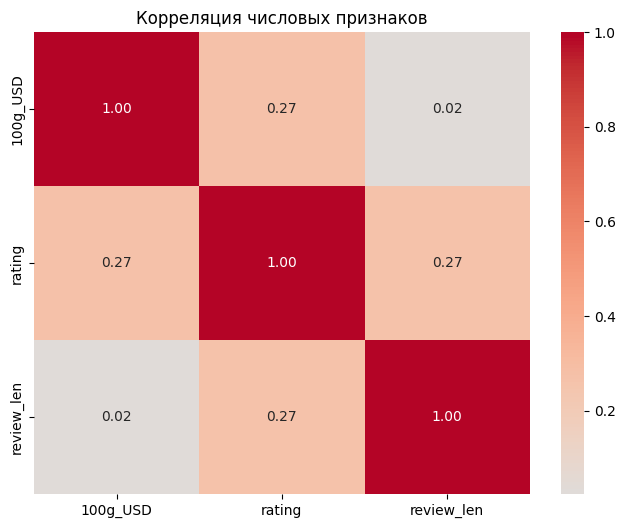

In [35]:
num_cols = df.select_dtypes(include="number")

corr = num_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Корреляция числовых признаков")
plt.show()

**Вывод:** Анализ распределения числовых признаков показал следующее:

- `rating` — распределение имеет умеренную левостороннюю асимметрию (коэффициент -0,798), что указывает на смещение в сторону более высоких оценок. Доля выбросов незначительна (1,16%), медиана практически совпадает со средним, что говорит о стабильности распределения без сильных отклонений.

- `review_len` — распределение близко к симметричному (коэффициент 0,298), с небольшим правосторонним скосом. Доля выбросов составляет 3,02%, что умеренно, но медиана и среднее практически совпадают, указывая на отсутствие сильных искажений.

- `100g_USD` — распределение характеризуется сильной правосторонней асимметрией (коэффициент 5,730), что подтверждается значительным расхождением медианы (5,86) и среднего (8,97). Доля выбросов критически высока (13,46%), что указывает на наличие большого числа экстремально дорогих образцов, сильно влияющих на распределение.
- корреляция между признаким мала

Для rating и review_len распределение можно считать приемлемым для большинства моделей без дополнительной обработки. Для 100g_USD требуется обработка выбросов для улучшения качества модели.

### Задание 13

Проанализируйте распределения категориальных признаков `name`, `roaster`, `roast` и нормализованных признаков стран. Можно ли выделить топ самых часто встречаемых категорий, а редкие объединить в небольшую группу «Прочее»? Если да, предложите для каждого признака границы отсечения частоты, запишите все в виде короткого вывода.

In [36]:
def replace_rare(df, column, threshold):
    """
    Заменяет редкие категории (встречающиеся меньше threshold раз) на "Other"
    """
    counts = df[column].value_counts()
    rare_categories = counts[counts < threshold].index

    df[column] = df[column].apply(
        lambda x: 'Other' if x in rare_categories else x
    )
    return df

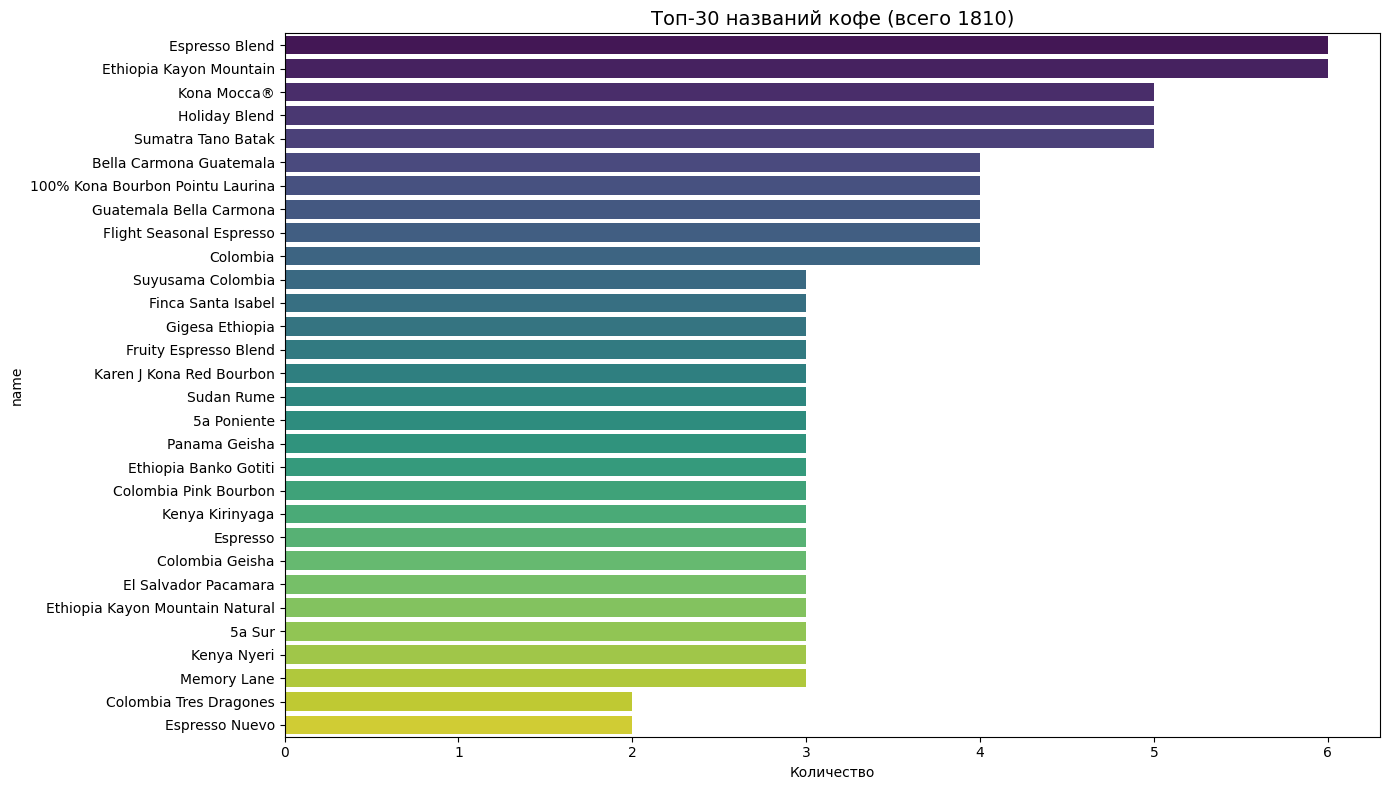

In [37]:
plt.figure(figsize=(14, 8))
name_counts = df['name'].value_counts().head(30)
sns.barplot(y=name_counts.index, x=name_counts.values, palette='viridis')
plt.title(f'Топ-30 названий кофе (всего {df["name"].nunique()})', fontsize=14)
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

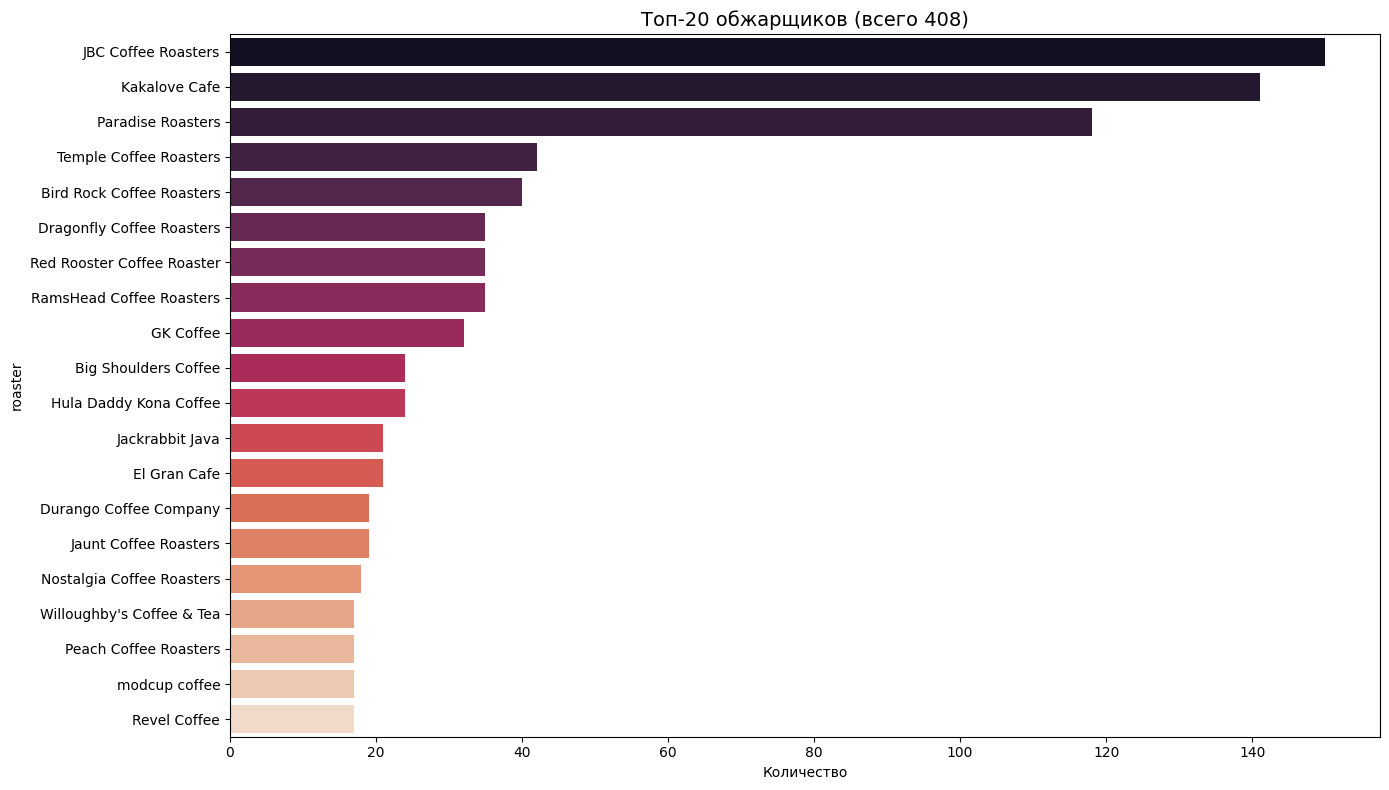

In [38]:
plt.figure(figsize=(14, 8))
roaster_counts = df['roaster'].value_counts().head(20)
sns.barplot(y=roaster_counts.index, x=roaster_counts.values, palette='rocket')
plt.title(f'Топ-20 обжарщиков (всего {df["roaster"].nunique()})', fontsize=14)
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

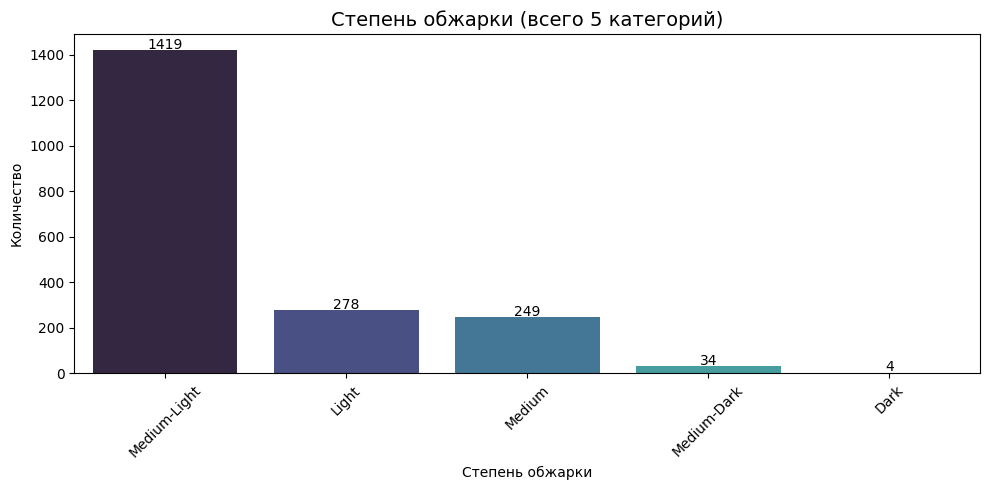

In [39]:
plt.figure(figsize=(10, 5))
roast_counts = df['roast'].value_counts()
sns.barplot(x=roast_counts.index, y=roast_counts.values, palette='mako')
plt.title(f'Степень обжарки (всего {df["roast"].nunique()} категорий)', fontsize=14)
plt.xlabel('Степень обжарки')
plt.ylabel('Количество')
plt.xticks(rotation=45)
for i, v in enumerate(roast_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

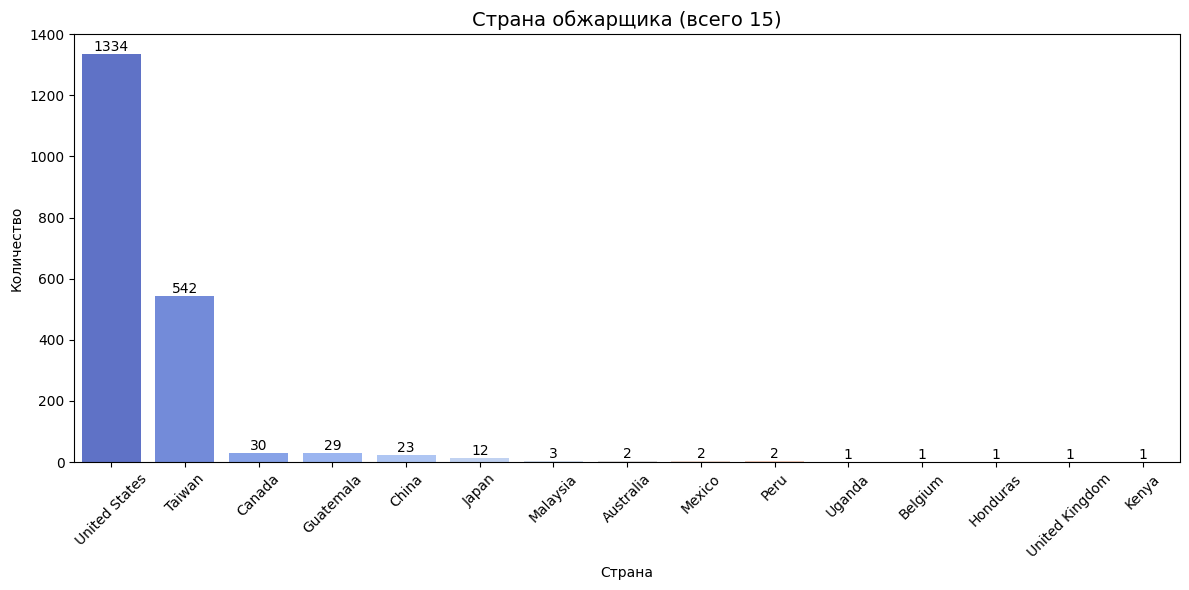

In [40]:
plt.figure(figsize=(12, 6))
country_counts = df['loc_country'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values, palette='coolwarm')
plt.title(f'Страна обжарщика (всего {df["loc_country"].nunique()})', fontsize=14)
plt.xlabel('Страна')
plt.ylabel('Количество')
plt.xticks(rotation=45)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

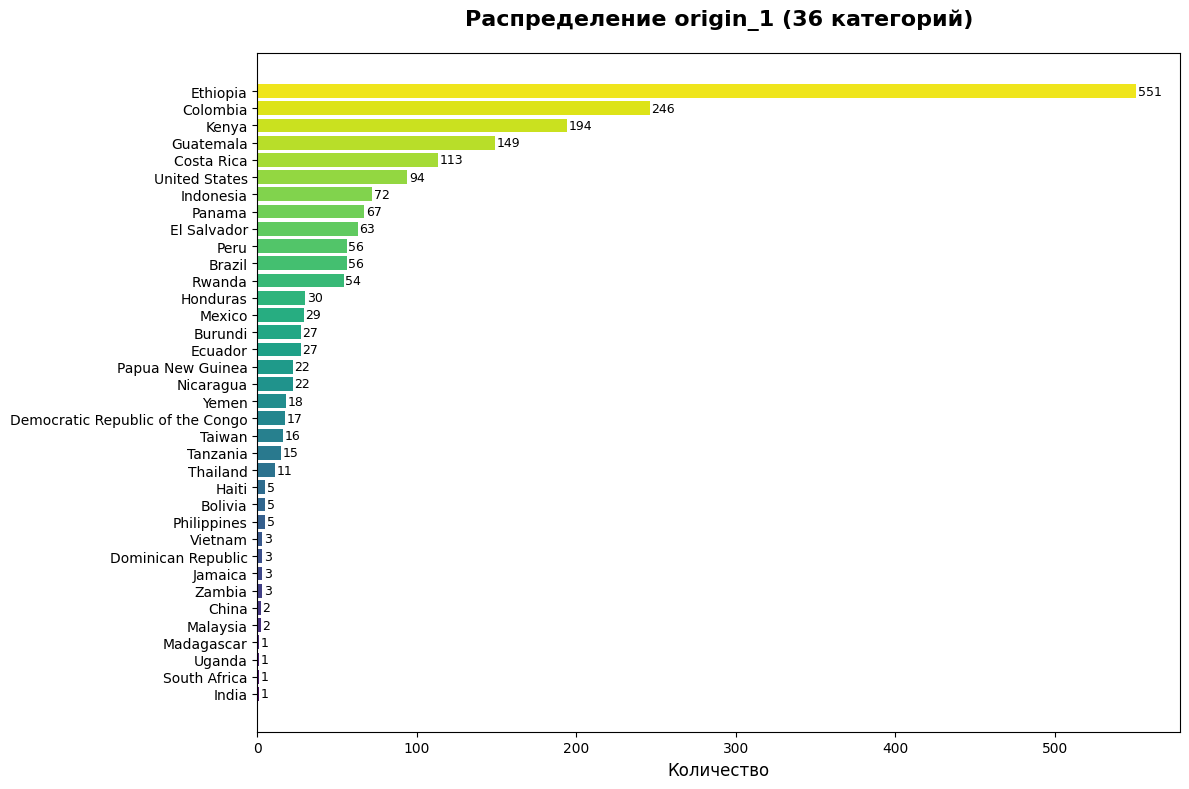

In [41]:
plt.figure(figsize=(12, 8))
origin1_counts = df['origin_1'].value_counts().sort_values(ascending=True)
colors = sns.color_palette("viridis", len(origin1_counts))
bars = plt.barh(origin1_counts.index, origin1_counts.values, color=colors)
plt.title('Распределение origin_1 (36 категорий)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Количество', fontsize=12)

# Добавляем значения на столбцы
for i, (val, bar) in enumerate(zip(origin1_counts.values, bars)):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

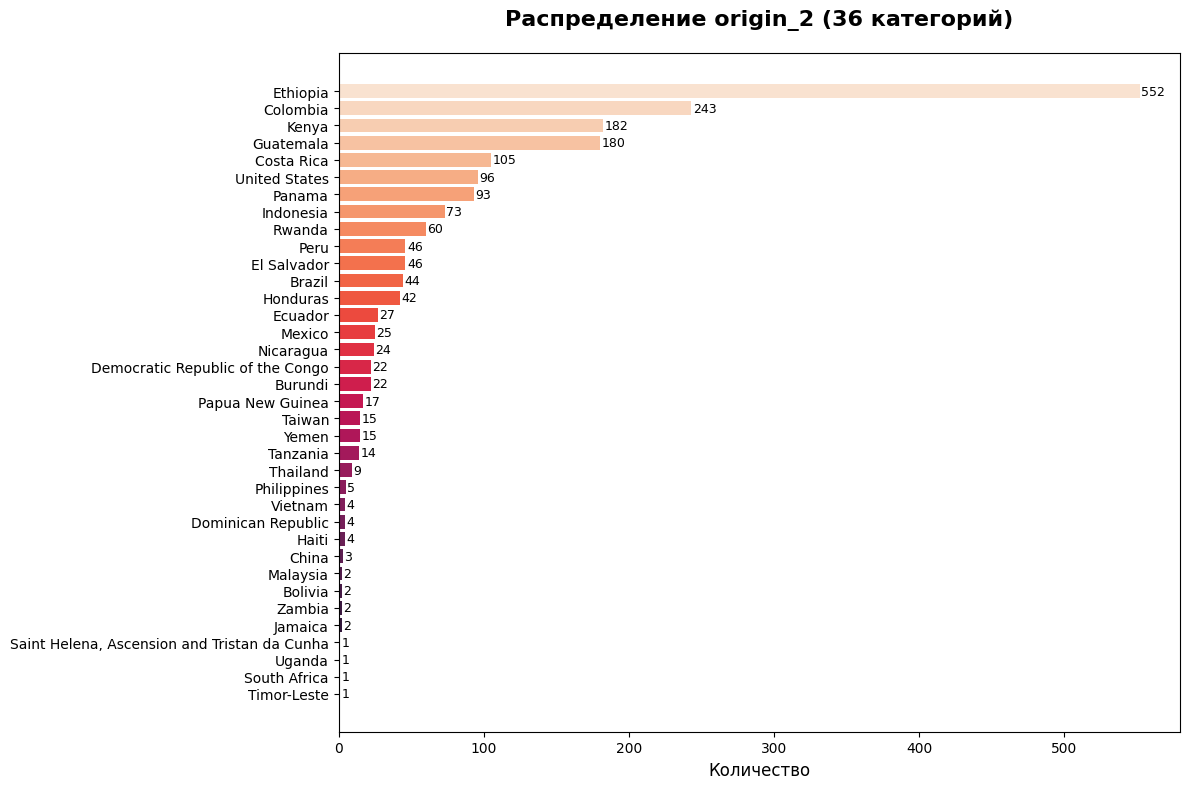

In [42]:
plt.figure(figsize=(12, 8))
origin2_counts = df['origin_2'].value_counts().sort_values(ascending=True)
colors = sns.color_palette("rocket", len(origin2_counts))
bars = plt.barh(origin2_counts.index, origin2_counts.values, color=colors)
plt.title('Распределение origin_2 (36 категорий)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Количество', fontsize=12)

# Добавляем значения на столбцы
for i, (val, bar) in enumerate(zip(origin2_counts.values, bars)):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
df = replace_rare(df, 'loc_country', 12)
df = replace_rare(df, 'origin_1', 4)
df = replace_rare(df, 'origin_2', 4)

Дополнительно посмотрим на корреляцию категориальных признаков. Для этого воспользуемся матрицей V Крамера

In [44]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()

    r, k = ct.shape
    phi2 = chi2 / n

    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)

    return np.sqrt(phi2_corr / max(1, min(r_corr - 1, k_corr - 1)))

In [45]:
def cramers_v_matrix(df):
    cols = df.columns
    corr = pd.DataFrame(
        np.eye(len(cols)),
        index=cols,
        columns=cols
    )

    for i, col1 in enumerate(cols):
        for j in range(i + 1, len(cols)):
            value = cramers_v(df[col1], df[cols[j]])
            corr.iloc[i, j] = value
            corr.iloc[j, i] = value

    return corr

In [46]:
cramers_corr = cramers_v_matrix(df[['name', 'roaster', 'roast', 'loc_country', 'origin_1', 'origin_2']])
cramers_corr

,name,roaster,roast,loc_country,origin_1,origin_2
name,1.000000,0.219892,0.184929,0.224528,0.271113,0.238773
roaster,0.219892,1.000000,0.506104,0.889457,0.254824,0.231572
roast,0.184929,0.506104,1.000000,0.090626,0.156657,0.116779
loc_country,0.224528,0.889457,0.090626,1.000000,0.240051,0.210551
origin_1,0.271113,0.254824,0.156657,0.240051,1.000000,0.740395
origin_2,0.238773,0.231572,0.116779,0.210551,0.740395,1.000000


**Вывод:** По результату проведенного анализа можно сделать следующие выводы:
- `name` предлагается удалить, так как большое число уникальных признаков;
- `roaster` предлагается не вводить порог, так как распредление довольно равномерное и огромное количество обжарщиков встречаются лишь один раз. Для кодировки признака предлагается Frequency Encoding
- `roast` признак имеет естественный порядок, поэтому может быть закодирован с помощью Ordinal Encoding
- `loc_country` в качестве порога можно выбрать 6 первых стран, остальное в прочее. Способ кодирования OHE
- `origin_1` и `origin_2` предлагается сделать порог 4. Способ кодирования OHE

Также необходимо отметить, что после дополнительно проведенного корреляционного анализа можно сделать следующие выводы:
- имеем сильную линейную связь между `roaster` и `loc_country` (0.87), в связи с этим `loc_country` можно исключить из модели.
- также имеем сильную линейную связь между `origin_1` и `origin_2`, в связи с этим `origin_2` можно исключить из модели.

Если удалить данные признаки, то после кодирования удастся сократить количество признаков с 66 -> 36, что улучшит качество модели.

Однако ввиду того, что в задании не сказано о том что необходимо проверить признаки на мультиколлинеарность далее я не буду исключать вышеуказанные признаки.



## Отбор и преобразование признаков

Наконец, приступим к последней части — финальному преобразованию признаков перед моделированием:
* закодируем категориальные;
* удалим оставшиеся лишние признаки;
* масштабируем числовые.


### Задание 14

Выберите подходящий способ кодирования категориальных признаков, не учитывайте редкие категории по выбранным в предыдущем задании порогам. Напишите, почему выбрали такой способ.

Закодируем `roaster` с помощью Frequency Encoding

In [47]:
df['roaster'] = df['roaster'].map(df['roaster'].value_counts() / len(df))

Закодируем `roast` с помощью OrdinalEncoder

In [48]:
roast_order = [['Light', 'Medium-Light', 'Medium', 'Medium-Dark', 'Dark']]
oe = preprocessing.OrdinalEncoder(categories=roast_order)

df['roast'] = oe.fit_transform(df[['roast']])

Закодируем `loc_country` с помощью OneHotEncoder. Для удобства создадим функцию

In [49]:
def one_hot_encode_column(df, column, drop_other=True):
    """
    One-Hot Encoder для одной колонки
    """
    ohe = preprocessing.OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore"
    )

    encoded = ohe.fit_transform(df[[column]])
    columns = ohe.get_feature_names_out([column])

    encoded_df = pd.DataFrame(
        encoded,
        columns=columns,
        index=df.index
    )

    # Удаляем Other
    other_col = f'{column}_Other'
    if drop_other and other_col in encoded_df.columns:
        encoded_df = encoded_df.drop(other_col, axis=1)

    df = pd.concat([df, encoded_df], axis=1)

    df = df.drop(column, axis=1)

    return df

Закодируем `origin_1` и `origin_2` с помощью OneHotEncoder

In [50]:
df.shape

(1984, 10)

In [51]:
df = one_hot_encode_column(df, 'loc_country')
df = one_hot_encode_column(df, 'origin_1')
df = one_hot_encode_column(df, 'origin_2')

In [52]:
df.shape

(1984, 66)

**Вывод:** По итогу кодирования категориальных признаков получили из 10 признаков 66. Ниже представлено объяснение как и почему закодирован каждый признак:
- `Roaster` закодировали Frequency Encoding, потому что при 409 категориях OHE создал бы сотни признаков, а этот метод сжимает всю информацию в один числовой признак, избегая «проклятия размерности».
- `roast` с помощью OrdinalEncoder так как признак имеет естественный порядок
- `loc_country`, `origin_1` и `origin_2` с помощью OneHotEncoder

### Задание 15

Выберите подходящий способ масштабирования числовых признаков и при необходимости таргета. Обоснуйте выбор.

In [53]:
scaler = preprocessing.StandardScaler()
df[['rating', 'review_len']] = scaler.fit_transform(df[['rating', 'review_len']])

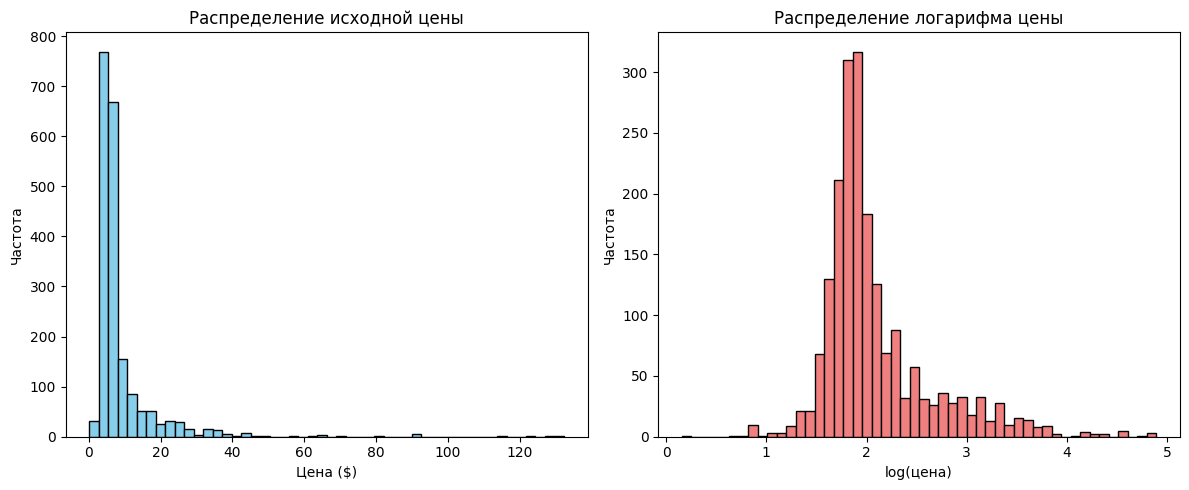

In [54]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['100g_USD'], bins=50, edgecolor='black', color='skyblue')
plt.title('Распределение исходной цены')
plt.xlabel('Цена ($)')
plt.ylabel('Частота')

# Логарифм цены
plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['100g_USD']), bins=50, edgecolor='black', color='lightcoral')
plt.title('Распределение логарифма цены')
plt.xlabel('log(цена)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [55]:
df['100g_USD'] = np.log1p(df['100g_USD'])

**Вывод:**
- для `rating` и `review_len` используем StandardScaler (нет сильных выбросов),
- для таргета `100g_USD` используем логарифмирование, так как распредление становится ближе к нормальному.

### Задание 16

Объедините все преобразованные признаки в единый датафрейм, удалите лишние и разделите датасет на тренировочную и тестовую выборки. Соотношение train/test можно взять 80/20.

Удалим лишнее

In [56]:
df = df.drop('name', axis=1)

Разделим датасет на тренировочную и тестовую выборки

In [57]:
X = df.drop(columns=['rating', 'review_date'])

Y = df['rating']

x_train, x_test, y_train, y_test = model_selection.train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=None
)

### Задание 17

Отберите 30 лучших признаков для предсказания целевой переменной при помощи `SelectKBest`. Выведите на экран  названия отобранных признаков.

In [58]:
# инициализируем
selector = SelectKBest(score_func=f_regression, k=30)

# обучаем
selector.fit(X, Y)

selected_features_mask = selector.get_support()
selected_feature_names = X.columns[selected_features_mask]

print("Отобранные 30 лучших признаков:")
for feature in selected_feature_names:
    print(feature)

Отобранные 30 лучших признаков:
roaster
roast
100g_USD
review_len
loc_country_Guatemala
loc_country_Taiwan
loc_country_United States
origin_1_Bolivia
origin_1_Brazil
origin_1_Ethiopia
origin_1_Guatemala
origin_1_Haiti
origin_1_Kenya
origin_1_Mexico
origin_1_Panama
origin_1_Philippines
origin_1_Rwanda
origin_1_Tanzania
origin_1_Thailand
origin_2_Brazil
origin_2_Ethiopia
origin_2_Guatemala
origin_2_Haiti
origin_2_Honduras
origin_2_Kenya
origin_2_Mexico
origin_2_Panama
origin_2_Rwanda
origin_2_Tanzania
origin_2_Thailand


Позравляем! Вы подготовили все к последнему этапу — машинному обучению. Ниже код константного алгоритма с семинара, можете запустить его и проверить качество базовой модели:)

In [59]:
# Константное предсказание — среднее по train
y_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

# Метрики
mse = metrics.mean_squared_error(y_test, y_pred)
mape = metrics.mean_absolute_percentage_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f}")

MSE: 1.0948
MAPE: 0.9636


### Задание 18*
Проведите анализ временного ряда средней цены кофе.

1. Убедитесь, что признак `review_date` приведен в формат `datetime`.
2. Агрегируйте данные по месяцам, вычислив среднюю цену `100g_USD`.
3. Постройте временной ряд средней цены кофе.
4. Выполните аддитивную декомпозицию временного ряда на тренд, сезонность и шум.
5. Проанализируйте полученные компоненты и сделайте вывод:
   - присутствует ли тренд;
   - наблюдается ли сезонность;
   - насколько велика шумовая компонента.

Напишите код и краткий вывод (3–5 предложений).


Для начала проверим тип

In [60]:
df['review_date'].dtype

dtype('<M8[ns]')

Агрегируем по месяцам и средней цене

In [61]:
df['year_month'] = df['review_date'].dt.to_period('M')

df['100g_USD'] = np.expm1(df['100g_USD']) # обратное преобразование

# Агрегируем по месяцам
monthly_avg_price = df.groupby('year_month')['100g_USD'].mean().reset_index()

print(monthly_avg_price)

   year_month   100g_USD
0     2017-11   7.023421
1     2017-12   9.150714
2     2018-01  20.283333
3     2018-02   6.021905
4     2018-03   5.728571
..        ...        ...
56    2022-07   9.410000
57    2022-08   6.657692
58    2022-09   9.098182
59    2022-10   7.929000
60    2022-11   6.090000

[61 rows x 2 columns]


Построим временной ряд средней цены

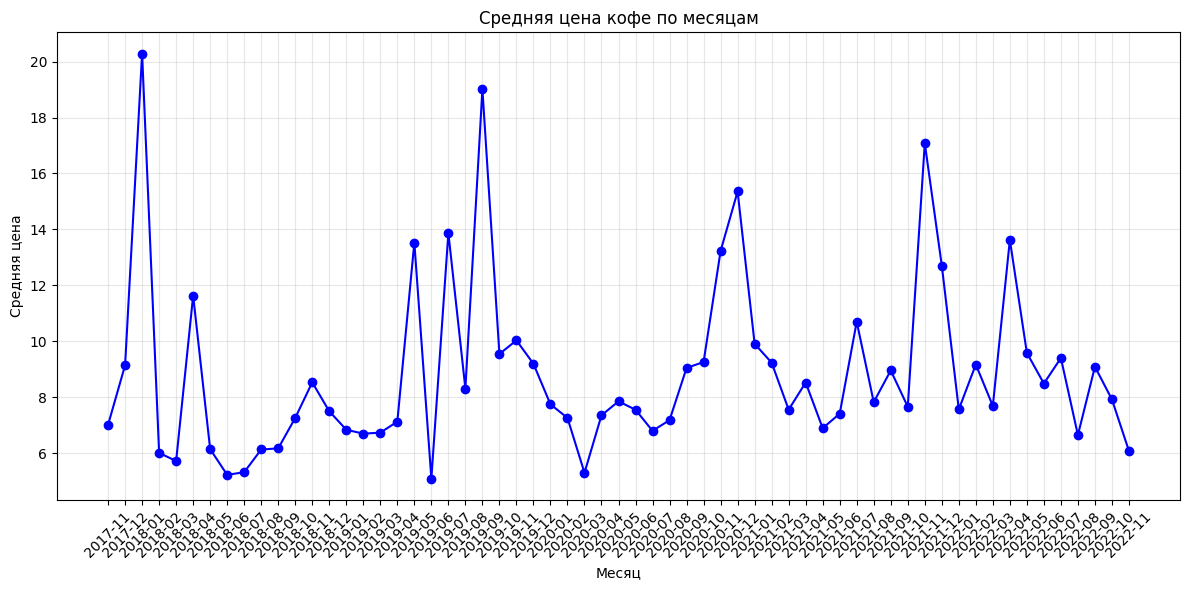

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_price['year_month'].astype(str), monthly_avg_price['100g_USD'],
         marker='o', linestyle='-', color='blue')
plt.title('Средняя цена кофе по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средняя цена')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Декомпозируем временной ряд

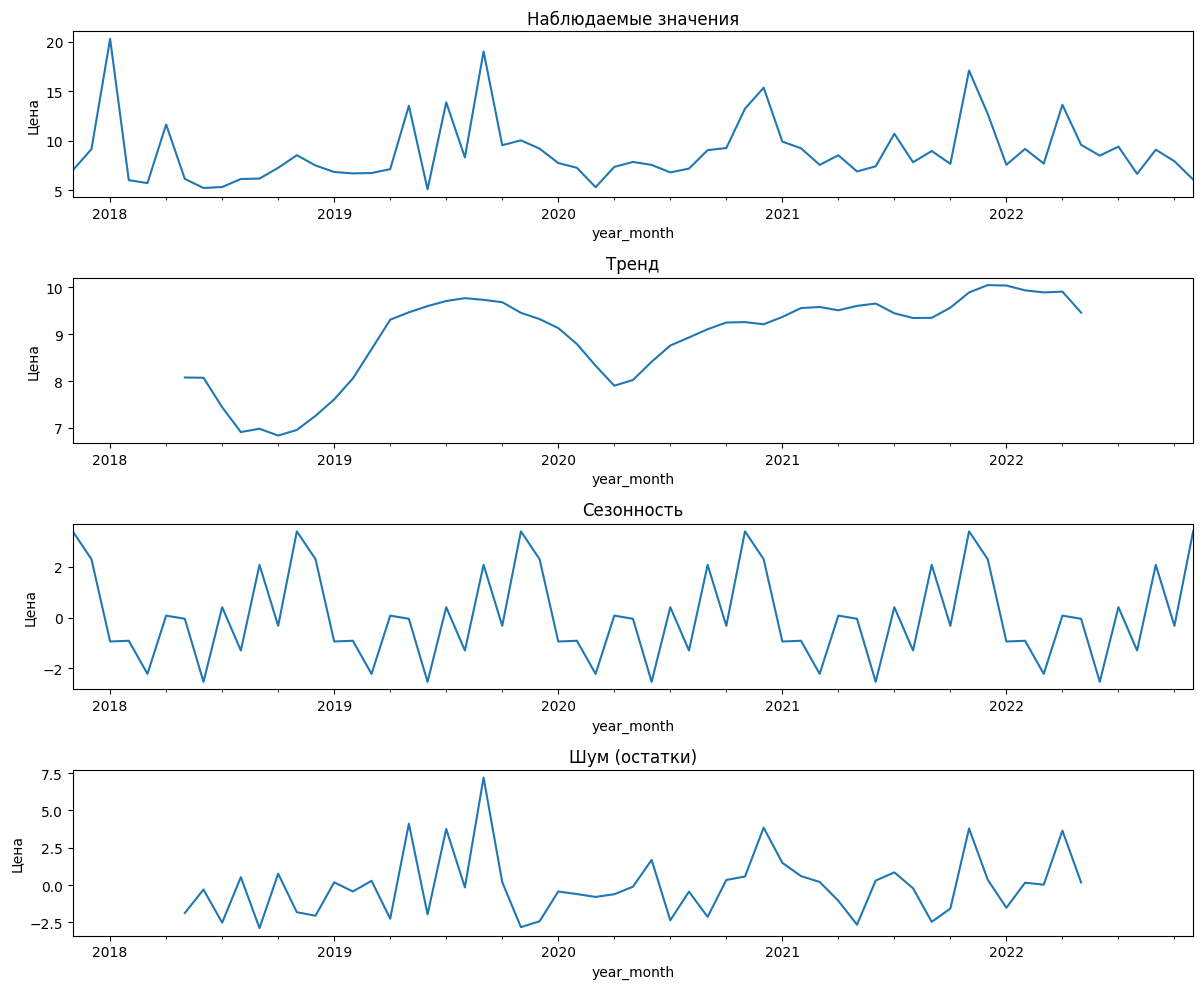

In [63]:
ts = monthly_avg_price.set_index('year_month')['100g_USD']
ts.index = ts.index.to_timestamp()  # преобразуем период в timestamp

# Выполняем аддитивную декомпозицию
decomposition = seasonal_decompose(ts, model='additive', period=12)

# Строим графики
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], title='Наблюдаемые значения')
axes[0].set_ylabel('Цена')

decomposition.trend.plot(ax=axes[1], title='Тренд')
axes[1].set_ylabel('Цена')

decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
axes[2].set_ylabel('Цена')

decomposition.resid.plot(ax=axes[3], title='Шум (остатки)')
axes[3].set_ylabel('Цена')

plt.tight_layout()
plt.show()

**Вывод:** После анализа компонент временного ряда можнос делать следующие выводы:
- **Тренд**: На графике тренда наблюдается повышение средней цены кофе с течением времени, что указывает на наличие восходящего тренда.

- **Сезонность**: Сезонная компонента имеет четко выраженную периодическую структуру с повторяющимися пиками и спадами. Это свидетельствует о наличии сезонных колебаний цен.

- **Шум**: График шума имеет большую амплитуду колебаний, сопоставимую с амплитудой исходного ряда, что указывает на высокий уровень случайной составляющей — цены на кофе слабо предсказуемы и подвержены сильным нерегулярным колебаниям.